# Fake Job Postings EDA/Modeling

This dataset contains 18K job descriptions out of which about 800 are fake. The data consists of both textual information and meta-information about the jobs. The dataset can be used to create classification models which can learn the job descriptions which are fraudulent.



In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import ConfusionMatrixDisplay



In [86]:
jobs = pd.read_csv("fake_job_postings.csv")

# 1.  EDA

In [87]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [88]:
jobs

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


- Shape: (18 columns, 17880 instances)
    - 17 features
    - fraudulent: 0 = fake job, 1 = real job
- Purpose: 
    - build a model that can predict real or fake jobs 
    - identity key characteristics of real and fake jobs




### Data Cleaning

#### Missing Values

In [89]:
jobs.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

#### Trimming Whitespace

In [90]:
# trimming the white space from all of the columns 

jobs = jobs.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/var/folders/9v/1qlgr1rd10lcc_n0k60c9b940000gn/T/ipykernel_90464/3616784157.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  jobs = jobs.applymap(lambda x: x.strip() if isinstance(x, str) else x)


####  Investigating the imbalance

In [91]:
fake = jobs[jobs['fraudulent']== 1]

In [92]:
real = jobs[jobs['fraudulent']== 0]

In [93]:
print(f' {len(fake)} fake jobs and {len(real)} real jobs')

 866 fake jobs and 17014 real jobs


There is a large imbalance in the dataset for our target value. The proportion of real to fake jobs is approximately 20:1

Text(0.5, 1.0, 'Target Class: Legitimate = 0, Fraudulent = 1 ')

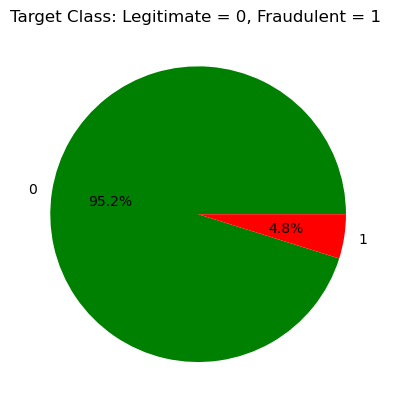

In [168]:
fraud_counts = jobs['fraudulent'].value_counts()
colors = ['green', 'red']
plt.pie(fraud_counts, labels=fraud_counts.index, autopct='%1.1f%%', colors = colors) 
plt.title("Target Class: Legitimate = 0, Fraudulent = 1 ")

### Industry 

In [95]:
industry_counts = jobs['industry'].value_counts()

rare_countries = industry_counts[industry_counts < 50].index

jobs['filtered_industry'] = jobs['industry'].apply(
    lambda x: 'Other' if x in rare_countries else x
)

jobs['filtered_industry'].value_counts()

jobs[jobs['filtered_industry']== 'Other']

jobs.drop(columns = 'industry') #dropping unfiltered column 

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,function,fraudulent,filtered_industry
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,Marketing,0,NaN
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Customer Service,0,Marketing and Advertising
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,0,NaN
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Sales,0,Computer Software
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Health Care Provider,0,Hospital & Health Care
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Sales,0,Computer Software
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Accounting/Auditing,0,Internet
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,0,NaN
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Design,0,Other


### Department

Most job postings comes from 
 
department
Sales                     564
Engineering               505
Marketing                 418
Operations                275
IT                        229
Development               153
Product                   113
Information Technology    100
Technology                 79
Design                     79
Name: count, dtype: int64


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sales'),
  Text(1, 0, 'Engineering'),
  Text(2, 0, 'Marketing'),
  Text(3, 0, 'Operations'),
  Text(4, 0, 'IT'),
  Text(5, 0, 'Development'),
  Text(6, 0, 'Product'),
  Text(7, 0, 'Information Technology'),
  Text(8, 0, 'Technology'),
  Text(9, 0, 'Design')])

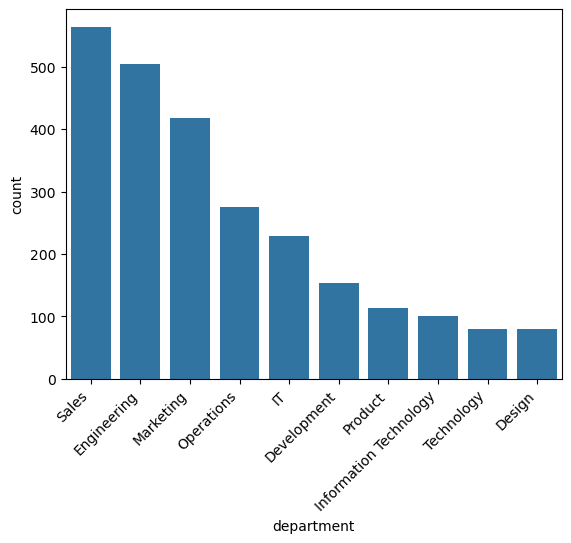

In [96]:
#jobs['department'] = jobs['department'].str.strip() 

top_departments = jobs['department'].value_counts()

top_ten_dep = top_departments.head(10)

print(f'Most job postings comes from \n \n{top_ten_dep}')

sns.barplot(x=top_ten_dep.index, y=top_ten_dep)

plt.xticks(rotation=45, ha='right') 

In [97]:
# Creating a separate dataframe for the most popular job postings

plot_subset = jobs[jobs['department'].isin(['Sales', 'Engineering', 'Marketing', 'Operations', 'IT', 'Development', 'Product', 'Information Technology', 'Design', 'Technology'])] 

In [98]:
subset_counts = plot_subset['department'].value_counts()
fake_sub_counts = plot_subset[plot_subset['fraudulent']==1]['department'].value_counts()

Number of Fake jobs per the most popular job postings 
 
department
Engineering               55
Information Technology    27
Sales                     12
Marketing                  2
IT                         1
Technology                 1
Name: count, dtype: int64


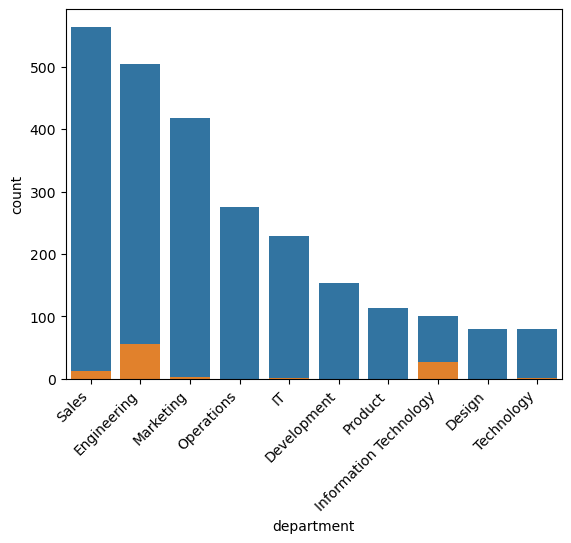

In [99]:
sns.barplot(x=subset_counts.index, y=subset_counts)
sns.barplot(x=fake_sub_counts.index, y=fake_sub_counts)

plt.xticks(rotation=45, ha='right') 

print(f'Number of Fake jobs per the most popular job postings \n \n{fake_sub_counts}')

In [100]:
len(jobs['department'].unique())

1278

In [101]:
value_counts = jobs['department'].value_counts()
print(value_counts)

department
Sales                    564
Engineering              505
Marketing                418
Operations               275
IT                       229
                        ... 
Residential/Community      1
Dojo                       1
AdOps                      1
OPERATIONS                 1
Administrative Dept        1
Name: count, Length: 1277, dtype: int64


In [102]:

# Filter values that appear only once
single_occurrences = (value_counts <= 2).sum()

to_replace = value_counts[value_counts <= 5].index

# If there are less 6 occurences of that department, then it is categorized as other 
jobs['department'] = jobs['department'].replace(to_replace, 'other')

len(jobs['department'].unique())


145

Text(0, 0.5, 'Count')

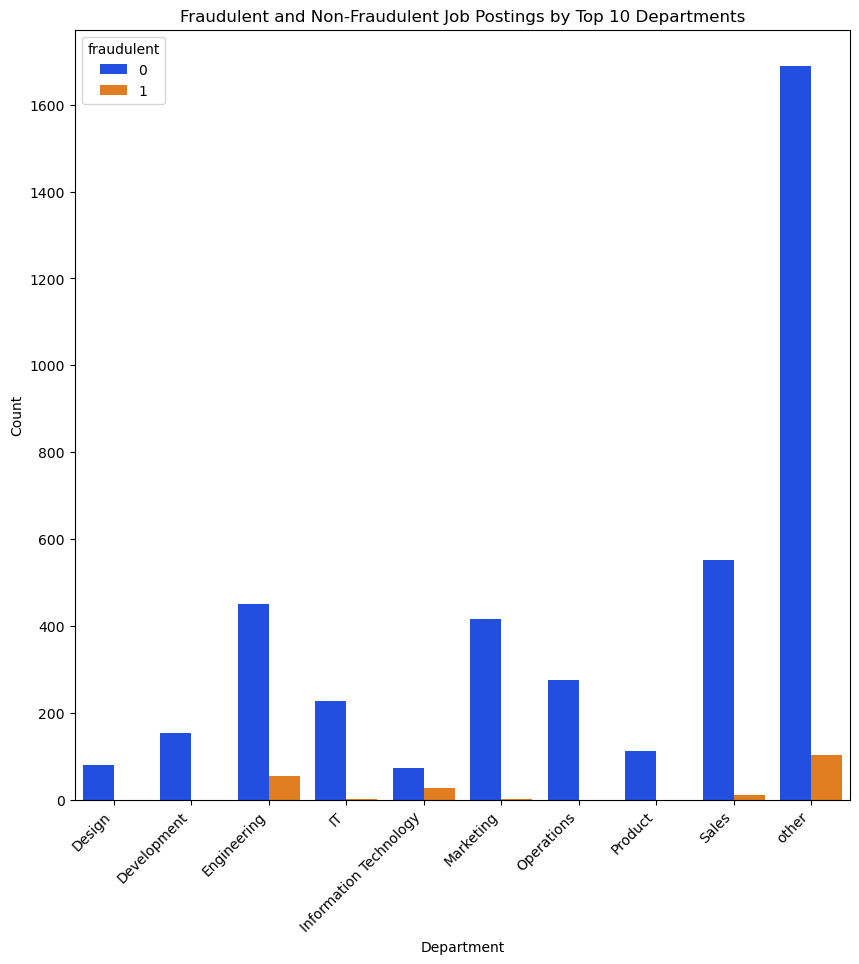

In [103]:
department_counts = jobs["department"].value_counts()

# Get the 10 largest departments
top_10_departments = department_counts.head(10).index

# Filter the dataset to include only the top 10 departments
filtered_df = jobs[jobs["department"].isin(top_10_departments)]


grouped = filtered_df.groupby(['department', 'fraudulent']).size().reset_index(name = "count")

plt.figure(figsize = (10,10))
sns.barplot(data = grouped, x = 'department', y = 'count', hue="fraudulent", palette="bright")
plt.xticks(rotation=45, ha='right') 

plt.title("Fraudulent and Non-Fraudulent Job Postings by Top 10 Departments")
plt.xlabel("Department")
plt.ylabel("Count")



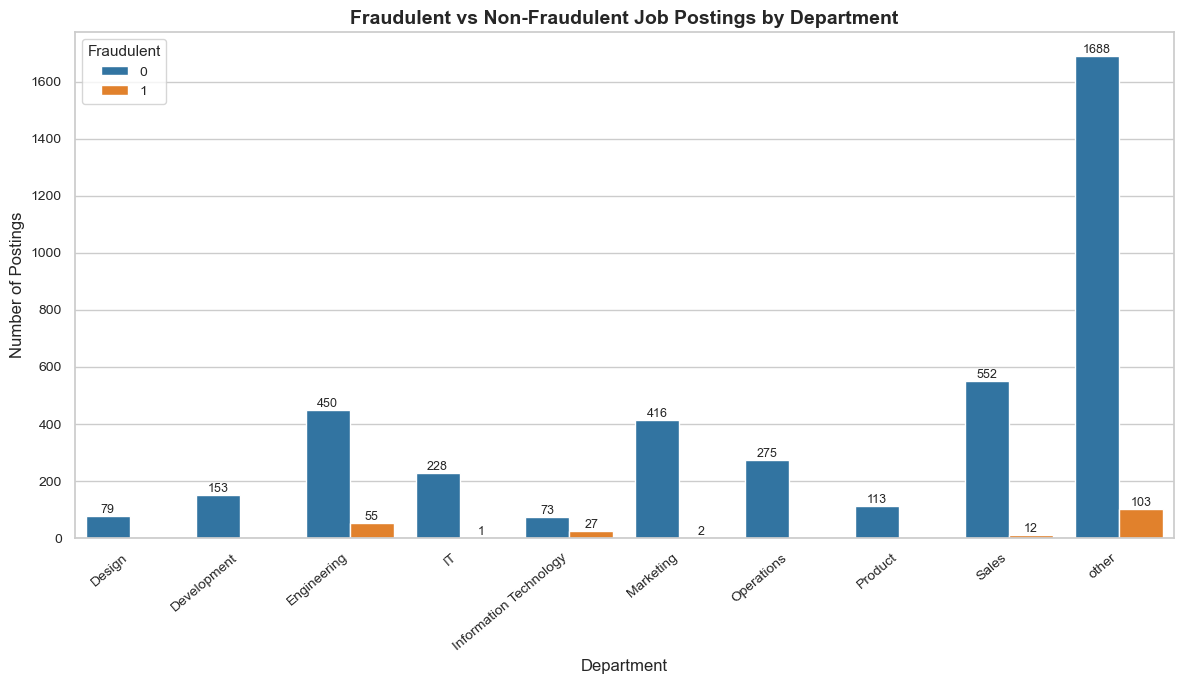

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Get department counts
department_counts = jobs["department"].value_counts()

# Top 10 departments
top_10_departments = department_counts.head(10).index
filtered_df = jobs[jobs["department"].isin(top_10_departments)]

# Group by department and fraud status
grouped = filtered_df.groupby(['department', 'fraudulent']).size().reset_index(name="count")

# Create figure
plt.figure(figsize=(12, 7))
barplot = sns.barplot(
    data=grouped,
    x='department',
    y='count',
    hue='fraudulent',
    palette=["#1f77b4", "#ff7f0e"]  # blue = non-fraud, orange = fraud
)

# Rotate x-axis labels
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Titles and labels
plt.title("Fraudulent vs Non-Fraudulent Job Postings by Department", fontsize=14, fontweight='bold')
plt.xlabel("Department", fontsize=12)
plt.ylabel("Number of Postings", fontsize=12)
plt.legend(title="Fraudulent", title_fontsize=11, fontsize=10)

# Add value labels on top of bars (optional)
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(f'{int(height)}', 
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

###  Salary 

In [104]:
unique_salaries = jobs["salary_range"].unique()

print(unique_salaries)



[nan '20000-28000' '100000-120000' '120000-150000' '50000-65000'
 '40000-50000' '60-80' '65000-70000' '75-115' '75000-110000' '17000-20000'
 '16000-28000' '95000-115000' '15000-18000' '50000-70000' '45000-60000'
 '30000-40000' '70000-90000' '10000-14000' '50-110' '28000-45000'
 '0-34300' '35000-40000' '9-Dec' '44000-57000' '18500-28000' '55000-75000'
 '30000-35000' '0-0' '20000-40000' '360000-600000' '50000-80000'
 '80000-100000' '52000-78000' '15750-15750' '40000-65000' '45000-50000'
 '30000-37000' '45000-67000' '35000-100000' '180000-216000' '45000-65000'
 '28000-32000' '0-1000' '36000-40000' '80000-110000' '35000-73000'
 '19000-19000' '60000-120000' '120000-15000000' '42000-55000'
 '90000-120000' '100000-150000' '28000-38000' '1600-1700' '50000-60000'
 '30000-70000' '32000-40000' '50-100' '9000-17000' '23040-28800' '105-110'
 '13000-16000' '100000-180000' '45000-55000' '9000-12000' '50000-90000'
 '25000-42000' '40000-60000' '600000-750000' '120000-170000' '45000-90000'
 '25000-30000

In [105]:
import math

unique_salaries = jobs["salary_range"].unique()

print(f'There are approximately {len(unique_salaries)} unique salaries')

missing_salaries = jobs["salary_range"].isna().sum()

print(f'There are approximately {missing_salaries} missing values- which corresponds to {missing_salaries/len(jobs)} percent of the jobs posted')

# The ranges lack consistency - some of the ranges are thousands (e.g. 20000-28000) while others are tens (e.g. 105 - 110). We cannot assume that 
# the ranges indicated by hundreds are meant to be annual rates in the thousands, they could also indicate hourly wages

# Some of the responses are also dates (e.g. 9-Dec) which is nonsensical for this category considering dates should not be related to a salary range 

# Because of this lack of consistency perhaps the better way to find the importance of salary is to identify if it is present or not 

# converting the "salary range" column into 0 (Nan) or 1 (some response given) 

jobs['Salary Given'] = jobs['salary_range'].fillna(0)

jobs['Salary Given'] = jobs['Salary Given'].apply(lambda x: 1 if x != 0 else x)

jobs['Salary Given'].value_counts()


There are approximately 875 unique salaries
There are approximately 15012 missing values- which corresponds to 0.8395973154362416 percent of the jobs posted


Salary Given
0    15012
1     2868
Name: count, dtype: int64

In [106]:
# plotting amount of fraudent jobs with salary given or not give

Text(0, 0.5, 'Count')

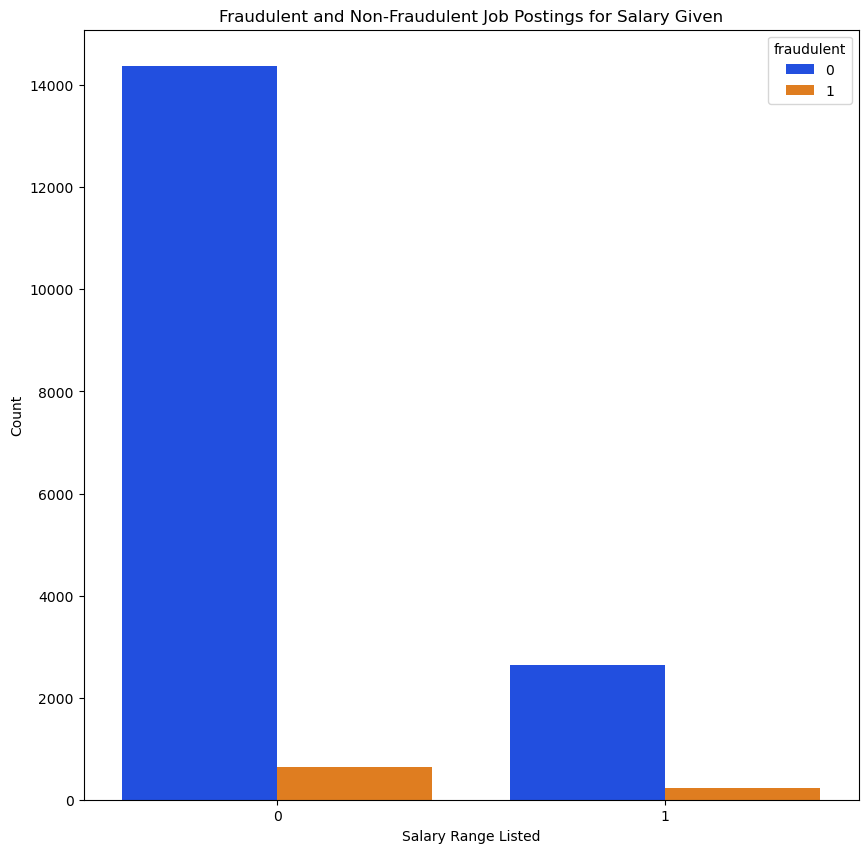

In [107]:
grouped = jobs.groupby(['Salary Given', 'fraudulent']).size().reset_index(name = "count")

plt.figure(figsize = (10,10))
sns.barplot(data = grouped, x = 'Salary Given', y = 'count', hue="fraudulent", palette="bright")


plt.title("Fraudulent and Non-Fraudulent Job Postings for Salary Given")
plt.xlabel("Salary Range Listed")
plt.ylabel("Count")


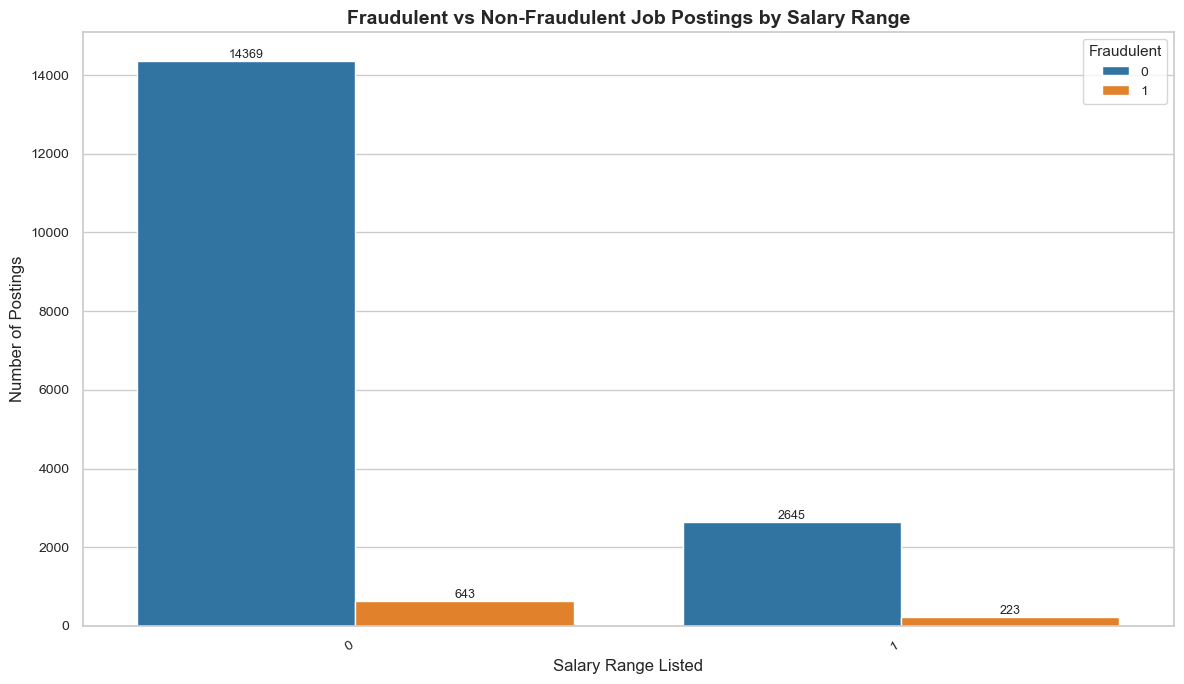

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Salary Given and Fraud Status
grouped = jobs.groupby(['Salary Given', 'fraudulent']).size().reset_index(name="count")

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 7))
barplot = sns.barplot(
    data=grouped,
    x='Salary Given',
    y='count',
    hue='fraudulent',
    palette=["#1f77b4", "#ff7f0e"]
)

# Improve label readability
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add value labels
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(f'{int(height)}', 
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Fraudulent vs Non-Fraudulent Job Postings by Salary Range", fontsize=14, fontweight='bold')
plt.xlabel("Salary Range Listed", fontsize=12)
plt.ylabel("Number of Postings", fontsize=12)
plt.legend(title="Fraudulent", title_fontsize=11, fontsize=10)

# Final layout
plt.tight_layout()
plt.show()


### Title

In [108]:
len(jobs['title'].unique())

10915

In [109]:
top_job_title = jobs['title'].value_counts()
top_job_title.head(10)


title
English Teacher Abroad                                406
Customer Service Associate                            198
Graduates: English Teacher Abroad (Conversational)    144
Customer Service Associate - Part Time                 91
Software Engineer                                      90
English Teacher Abroad (Conversational)                83
Account Manager                                        81
Project Manager                                        71
Web Developer                                          69
Customer Service Representative                        63
Name: count, dtype: int64

In [110]:
jobs['title'] = jobs['title'].str.strip() 

# creating homogeneity within the title columns 
mapping = {
    'Engineering': ['Engineering', 'engineering'],
    'Software Engineering': ['software', 'software engineer', 'process engineer', 'software developer'],
    'English Teacher Abroad': ['english teacher', 'English Teacher Abroad','Graduates: english teacher abroad (conversational)', 'english teacher abroad (conversational)', 'English Teacher Overseas']
}

# Function to map categories to their groups
def map_category(category):
    for group, synonyms in mapping.items():
        if category.lower() in synonyms:
            return group
    return category  # Return the original category if no match found

# Apply the mapping function to the 'Category' column
jobs['Grouped_Titles'] = jobs['title'].apply(map_category)

# Count the occurrences of each grouped category
category_counts = jobs['Grouped_Titles'].value_counts()

In [111]:
top_grouped_titles = category_counts.head(10)
print(top_grouped_titles)
top_titles_ind = top_grouped_titles.head(10).index
filtered_df = jobs[jobs['Grouped_Titles'].isin(top_titles_ind)]


Grouped_Titles
English Teacher Abroad                                490
Customer Service Associate                            198
Software Engineering                                  155
Graduates: English Teacher Abroad (Conversational)    144
Customer Service Associate - Part Time                 91
Account Manager                                        81
Project Manager                                        71
Web Developer                                          69
Customer Service Representative                        63
Beauty & Fragrance consultants needed                  60
Name: count, dtype: int64


In [112]:
len(jobs['Grouped_Titles'].unique())

10909

Text(0, 0.5, 'Count')

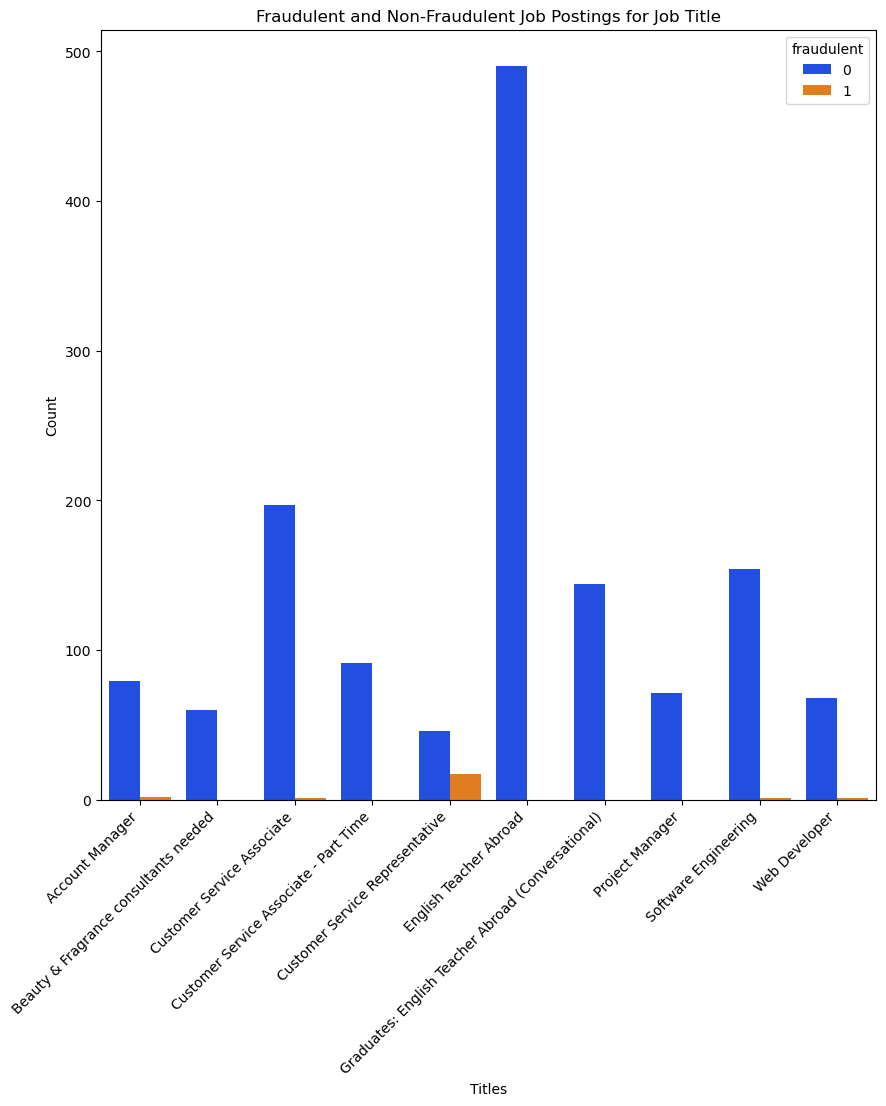

In [113]:
group_titles = filtered_df.groupby(['Grouped_Titles', 'fraudulent']).size().reset_index(name = "count")
plt.figure(figsize = (10,10))
sns.barplot(data = group_titles, x = 'Grouped_Titles', y = 'count', hue="fraudulent", palette="bright")
plt.xticks(rotation=45, ha='right') 

plt.title("Fraudulent and Non-Fraudulent Job Postings for Job Title")
plt.xlabel("Titles")
plt.ylabel("Count")

###  Location

Text(0, 0.5, 'Count')

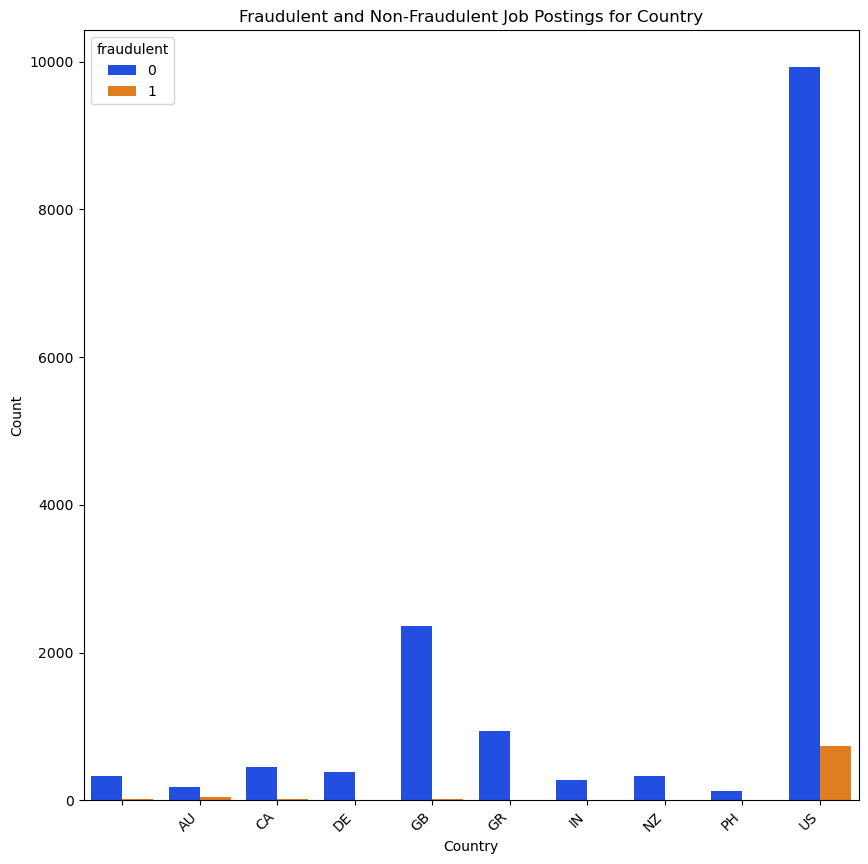

In [114]:
jobs['location'] = jobs['location'].str.strip() 

jobs['location'] = jobs['location'].fillna(' , , ')


job = jobs['location'].str.split(',', expand=True) 
jobs['Country'] = job[0]
jobs['Region'] = job[1]
jobs['City'] = job[2]


country = jobs['Country'].value_counts()
top_countries = country.head(10).index
filtered_country = jobs[jobs['Country'].isin(top_countries)]

group_titles = filtered_country.groupby(['Country', 'fraudulent']).size().reset_index(name = "count")
plt.figure(figsize = (10,10))
sns.barplot(data = group_titles, x = 'Country', y = 'count', hue="fraudulent", palette="bright")
plt.xticks(rotation=45, ha='right') 


plt.title("Fraudulent and Non-Fraudulent Job Postings for Country")
plt.xlabel("Country")
plt.ylabel("Count")

### Special Characters in title

In [115]:
def check_special_characters(title):
    """
    Checks if a job title contains special characters ("!", "urgent", "now").

    Args:
        title: The job title string.

    Returns:
        1 if the title contains any of the special characters, 0 otherwise.
    """
    if any(word in title.lower() for word in ["!", "urgent", "now", r"\*"]):
        return 1
    else:
        return 0
    
jobs['special_characters'] = jobs['title'].apply(check_special_characters)

In [116]:
jobs['special_characters'].value_counts()

special_characters
0    17606
1      274
Name: count, dtype: int64

Text(0, 0.5, 'Count')

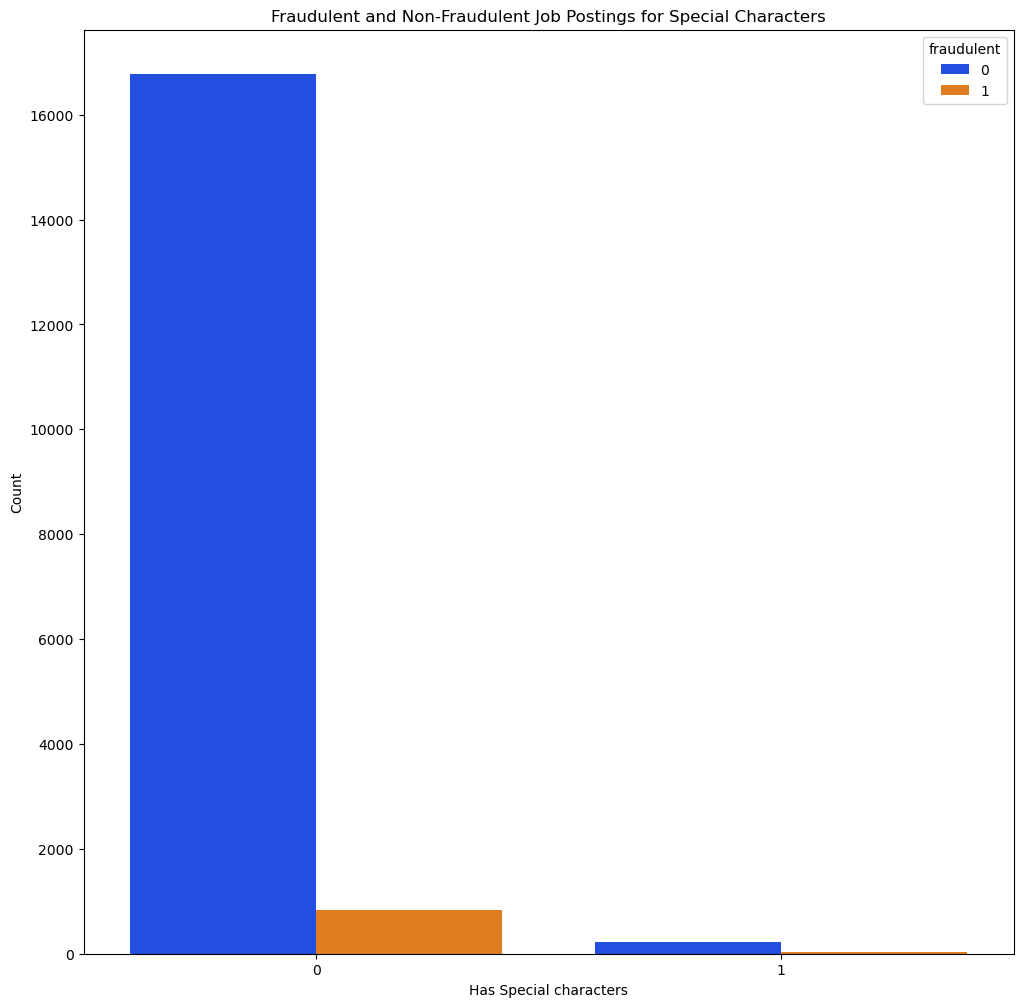

In [117]:
special_char = jobs['special_characters'].value_counts()
top_spec_char = special_char.head(10).index
filtered_char = jobs[jobs['special_characters'].isin(top_spec_char)]

group_char = filtered_char.groupby(['special_characters', 'fraudulent']).size().reset_index(name = "count")
plt.figure(figsize = (12,12))
sns.barplot(data = group_char, x = 'special_characters', y = 'count', hue="fraudulent", palette="bright")

plt.title("Fraudulent and Non-Fraudulent Job Postings for Special Characters")
plt.xlabel("Has Special characters")
plt.ylabel("Count")

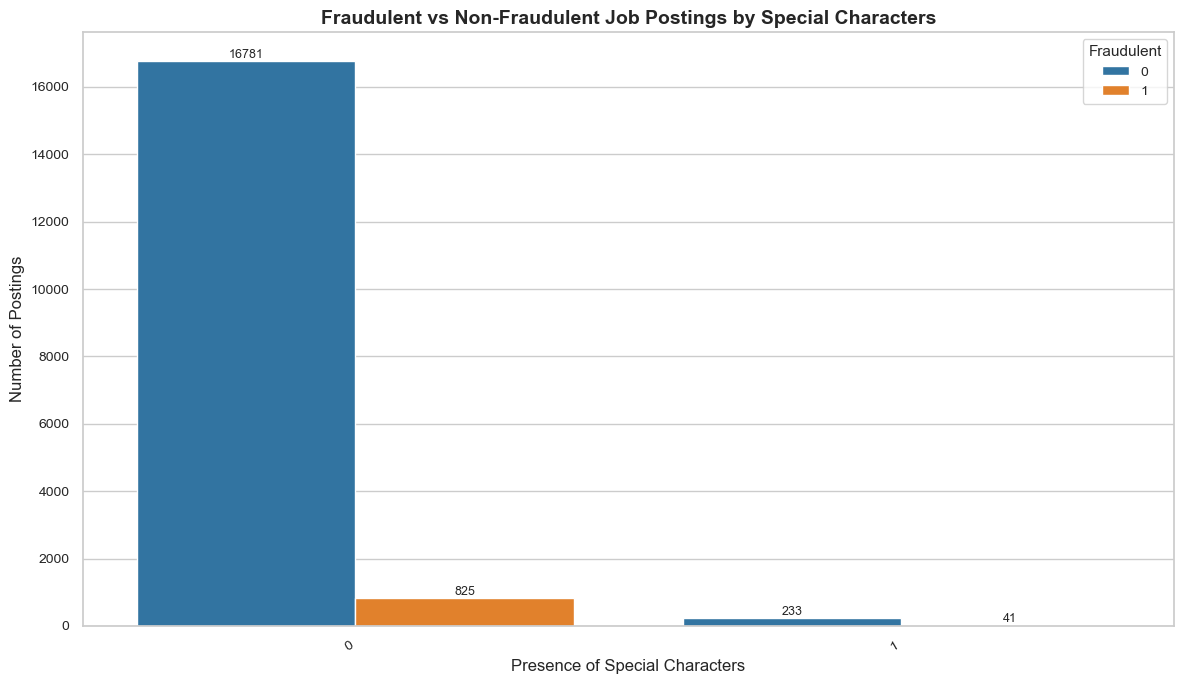

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count top 10 most common values in 'special_characters' column
special_char = jobs['special_characters'].value_counts()
top_spec_char = special_char.head(10).index
filtered_char = jobs[jobs['special_characters'].isin(top_spec_char)]

# Group by special_characters and fraud status
group_char = filtered_char.groupby(['special_characters', 'fraudulent']).size().reset_index(name="count")

# Set Seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(12, 7))
barplot = sns.barplot(
    data=group_char,
    x='special_characters',
    y='count',
    hue='fraudulent',
    palette=["#1f77b4", "#ff7f0e"]
)

# Customize x-axis
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add value labels to bars
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(f'{int(height)}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Fraudulent vs Non-Fraudulent Job Postings by Special Characters", fontsize=14, fontweight='bold')
plt.xlabel("Presence of Special Characters", fontsize=12)
plt.ylabel("Number of Postings", fontsize=12)
plt.legend(title="Fraudulent", title_fontsize=11, fontsize=10)

# Clean layout
plt.tight_layout()
plt.show()


Handling NaNs and drop useless columns

In [118]:
jobs = jobs.drop("location", axis = 1)
jobs = jobs.drop("job_id", axis = 1)

In [119]:
# jobs['salary_range'] = jobs['salary_range'].fillna("Na")

- split certain columns so that the information is binary (yes/no) 
    - employment type
    - required education
- can help the model learn by adding more specific characteristics like full time - yes or no or bachelor's degree required yes or no
- create a row that identifies if there is a blank in that row 

- consider making a binary column for descriptive text columns to identify the presence of key words like "urgent", "now" 

    - use n-grams for processing the large text portions

### Required Education

In [120]:
jobs['required_education'] = jobs['required_education'].str.strip() 

jobs['required_education'].unique()

value_counts = jobs['required_education'].value_counts(dropna = False)
print(value_counts)


required_education
NaN                                  8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64


Text(0, 0.5, 'Count')

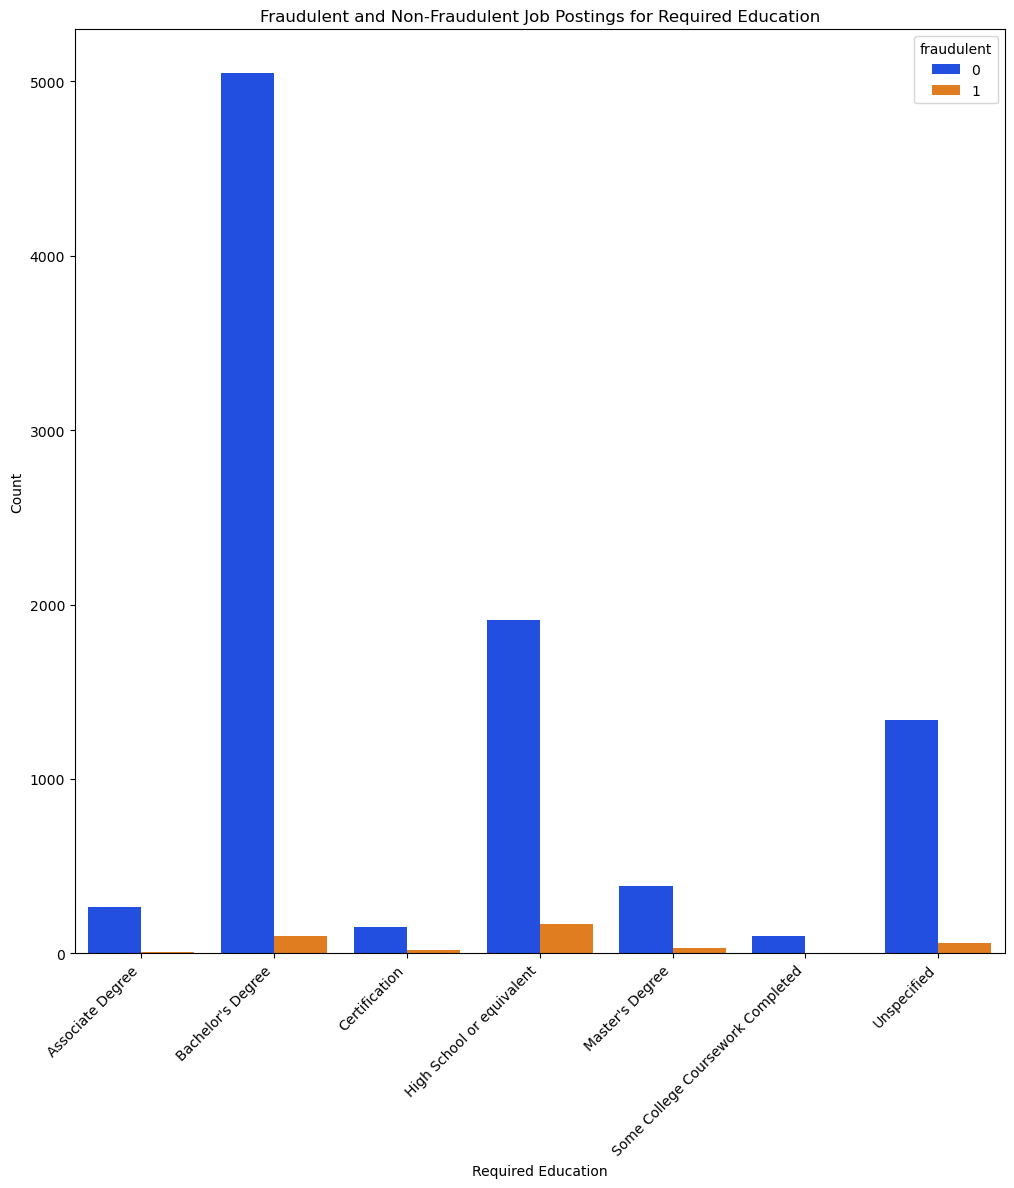

In [121]:
req_edu = jobs['required_education'].value_counts()
top_req_edu = req_edu.head(7).index
filtered_edu = jobs[jobs['required_education'].isin(top_req_edu)]

group_edu = filtered_edu.groupby(['required_education', 'fraudulent']).size().reset_index(name = "count")
plt.figure(figsize = (12,12))
sns.barplot(data = group_edu, x = 'required_education', y = 'count', hue="fraudulent", palette="bright")
plt.xticks(rotation=45, ha='right') 

plt.title("Fraudulent and Non-Fraudulent Job Postings for Required Education")
plt.xlabel("Required Education")
plt.ylabel("Count")

In [122]:
jobs['Bachelor_degree'] = jobs['required_education'].str.contains("Bachelor's Degree", na=False).astype(int)

jobs['High school or equivalent'] = jobs['required_education'].str.contains("High School or equivalent", na=False).astype(int)

jobs['Unspecified degree requirement'] = jobs['required_education'].str.contains("Unspecified", na=False).astype(int)

jobs['Masters_degree'] = jobs['required_education'].str.contains("Master's Degree", na=False).astype(int)

jobs['Associates degree'] = jobs['required_education'].str.contains("Associate Degree", na=False).astype(int)

jobs['Certification'] = jobs['required_education'].str.contains("Certification", na=False).astype(int)

jobs['Some College Coursework Completed'] = jobs['required_education'].str.contains("Some College Coursework Completed", na=False).astype(int)

### Required Experience

In [123]:
jobs['required_experience'].value_counts()

required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

In [124]:
jobs['Mid-Senior'] = jobs['required_experience'].str.contains("Mid-Senior level", na=False).astype(int)

jobs['Entry level'] = jobs['required_experience'].str.contains("Entry level", na=False).astype(int)

jobs['Associate'] = jobs['required_experience'].str.contains("Associate", na=False).astype(int)

jobs['Not Application'] = jobs['required_experience'].str.contains("Not Application", na=False).astype(int)

jobs['Director'] = jobs['required_experience'].str.contains("Director", na=False).astype(int)

jobs['Internship'] = jobs['required_experience'].str.contains("Internship", na=False).astype(int)


Text(0, 0.5, 'Count')

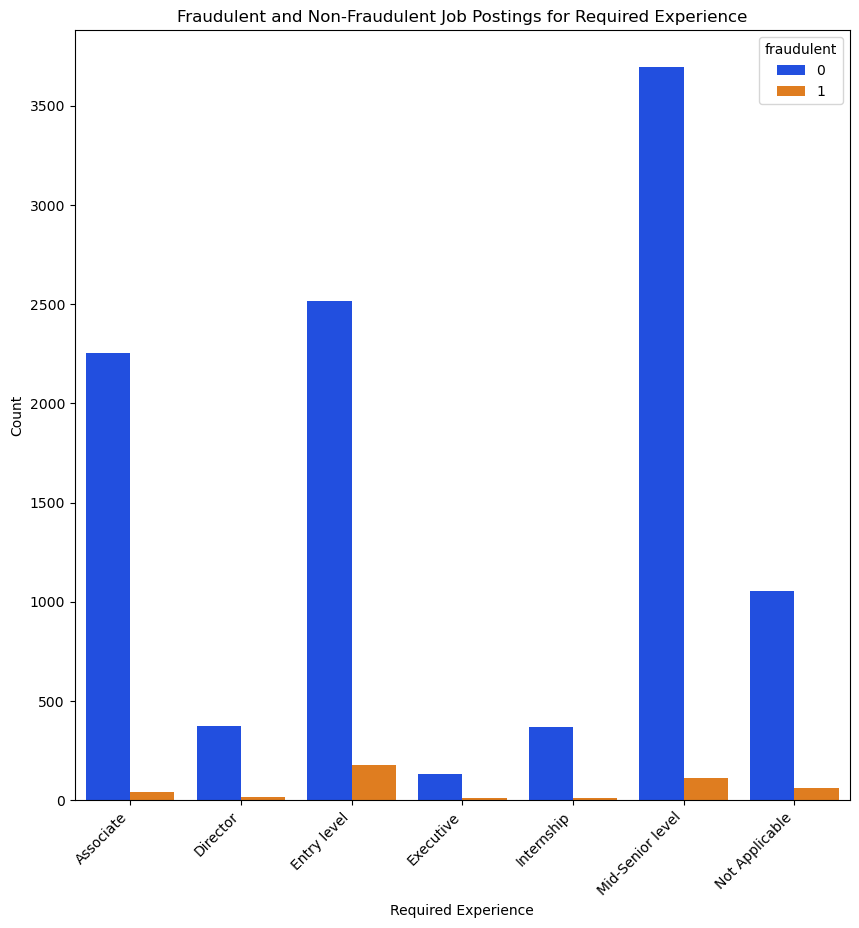

In [125]:
req_exp = jobs['required_experience'].value_counts()
top_req_exp = req_exp.head(7).index
filtered_exp = jobs[jobs['required_experience'].isin(top_req_exp)]

group_exp = filtered_exp.groupby(['required_experience', 'fraudulent']).size().reset_index(name = "count")
plt.figure(figsize = (10,10))
sns.barplot(data = group_exp, x = 'required_experience', y = 'count', hue="fraudulent", palette="bright")
plt.xticks(rotation=45, ha='right') 

plt.title("Fraudulent and Non-Fraudulent Job Postings for Required Experience")
plt.xlabel("Required Experience")
plt.ylabel("Count")

### Employment Type

In [126]:
jobs['employment_type'].isna().sum()

3471

In [127]:
emply_type = jobs['employment_type'].value_counts()
print(emply_type)

employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x1751a2e10>,
 [Text(-0.9028176743508518, 0.6284268031200766, 'Full-time'),
  Text(0.6975602443597653, -0.850534952537957, 'Contract'),
  Text(1.0224076523870003, -0.4058110303337049, 'Part-time'),
  Text(1.0873952729188272, -0.16604674171386127, 'Temporary'),
  Text(1.0986530278653546, -0.05441988939981824, 'Other')],
 [Text(-0.49244600419137363, 0.3427782562473145, '80.6%'),
  Text(0.3804874060144174, -0.46392815592979464, '10.6%'),
  Text(0.5576769013020001, -0.22135147109111175, '5.5%'),
  Text(0.5931246943193602, -0.0905709500257425, '1.7%'),
  Text(0.599265287926557, -0.029683576036264488, '1.6%')])

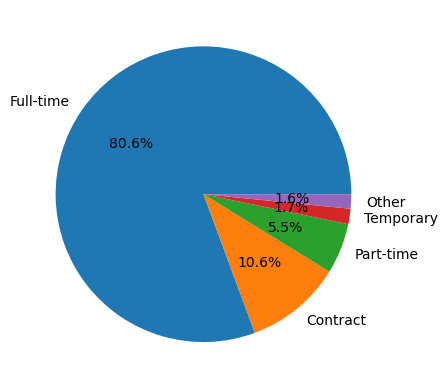

In [128]:
empl_type_counts = emply_type
plt.pie(emply_type, labels=emply_type.index, autopct='%1.1f%%') 

# fraud_counts = jobs['fraudulent'].value_counts()
# colors = ['green', 'red']
# plt.pie(fraud_counts, labels=fraud_counts.index, autopct='%1.1f%%', colors = colors) 

### Function

In [129]:
ind_counts = jobs['industry'].value_counts()
print(ind_counts)

industry
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
                                       ... 
Shipbuilding                              1
Sporting Goods                            1
Museums and Institutions                  1
Wine and Spirits                          1
Ranching                                  1
Name: count, Length: 131, dtype: int64


In [130]:
# Analyzing the impact of industry on the target value

target_impact = jobs.groupby('industry')['fraudulent'].mean()
top_target = target_impact.head(10)

<Axes: xlabel='industry'>

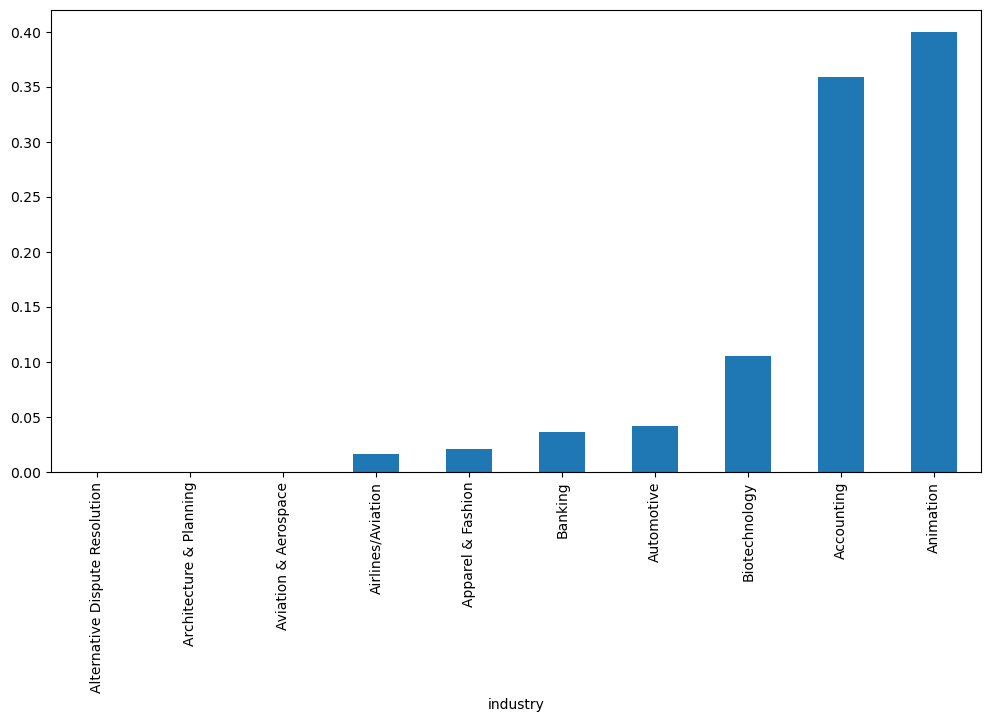

In [131]:
top_target.sort_values().plot(kind='bar', figsize=(12, 6))


 Because this feature has such high cardinality, to reduce the risk of overfitting, we should combine the rare responses into 'other' category

In [132]:
# Filter values that appear only once
rare_occurrences = (value_counts <= 10).sum()

to_replace = ind_counts[ind_counts <= 15].index

# If there are less 6 occurences of that department, then it is categorized as other 
jobs['industry'] = jobs['industry'].replace(to_replace, 'other')

len(jobs['industry'].unique())

# jobs['industry'].value_counts()

81

# 2. Dimensionality Reduction

### Dropping Redudant Columns

In [133]:
jobs = jobs.drop("required_experience", axis = 1)

In [134]:
jobs = jobs.drop("required_education", axis = 1)

In [135]:
jobs = jobs.drop("title", axis = 1)

In [136]:
jobs = jobs.drop("salary_range", axis = 1)

In [137]:
y = jobs['fraudulent']
X = jobs.drop(columns=['fraudulent'])

In [138]:
categorical_columns = X.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_columns)

Categorical columns: Index(['department', 'company_profile', 'description', 'requirements',
       'benefits', 'employment_type', 'industry', 'function',
       'filtered_industry', 'Grouped_Titles', 'Country', 'Region', 'City'],
      dtype='object')


In [139]:
binary_columns = X.select_dtypes(include=['int64']).columns
print("binary_columns:", binary_columns)

binary_columns: Index(['telecommuting', 'has_company_logo', 'has_questions', 'Salary Given',
       'special_characters', 'Bachelor_degree', 'High school or equivalent',
       'Unspecified degree requirement', 'Masters_degree', 'Associates degree',
       'Certification', 'Some College Coursework Completed', 'Mid-Senior',
       'Entry level', 'Associate', 'Not Application', 'Director',
       'Internship'],
      dtype='object')


### Correlation

In [140]:
corr = jobs[binary_columns].corr()

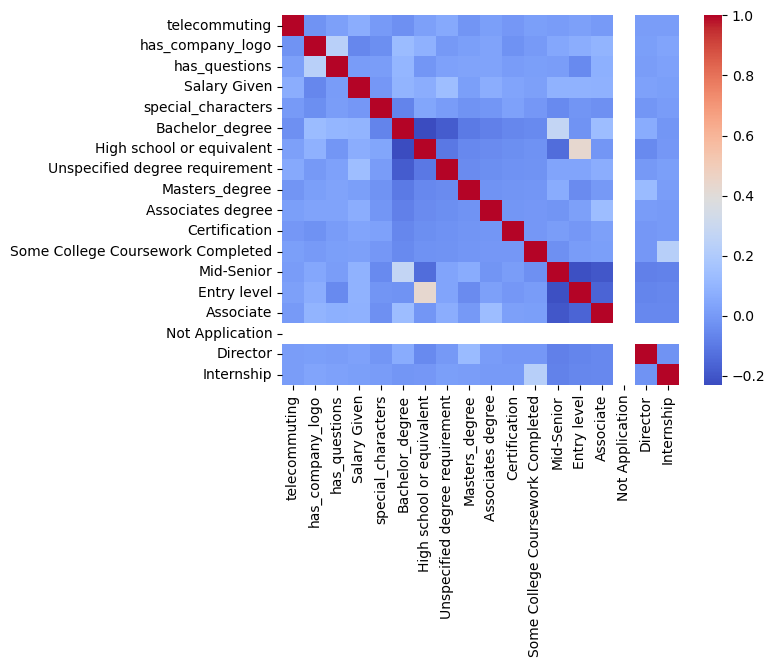

In [141]:
sns.heatmap(corr, cmap='coolwarm')
plt.show()

### PCA vs. LDA

- PCA:

    - May not be the best option because the data is not very highly correlated
    - PCA preforms better in unsupervised learning
    - loses interpretabiltiy 
    
- LDA
    
    - supervised method often used for feature selection and classification
    - goal is to find the linear combination of features that best separates the classes
    - seeks to keep information relevant for class discrimination


In [142]:
jobs.to_csv('jobs_clean.csv', index=False)

# 3. Logistic Regression

In [143]:
unique_values = jobs.nunique()
print(unique_values)

# Selecting Columns to be transformed by 'One Hot Encoder' that have 145 or less unique values
# after creating a new dataframe with these new columns, apply regualarization to reduce dimensionality 
selected_columns = unique_values[unique_values < 145].index

new_df = jobs[selected_columns]

department                             144
company_profile                       1709
description                          14666
requirements                         11899
benefits                              6080
telecommuting                            2
has_company_logo                         2
has_questions                            2
employment_type                          5
industry                                80
function                                37
fraudulent                               2
filtered_industry                       50
Salary Given                             2
Grouped_Titles                       10909
Country                                 91
Region                                 325
City                                  2219
special_characters                       2
Bachelor_degree                          2
High school or equivalent                2
Unspecified degree requirement           2
Masters_degree                           2
Associates 

### One hot encoding

In [144]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   department                         6333 non-null   object
 1   telecommuting                      17880 non-null  int64 
 2   has_company_logo                   17880 non-null  int64 
 3   has_questions                      17880 non-null  int64 
 4   employment_type                    14409 non-null  object
 5   industry                           12977 non-null  object
 6   function                           11425 non-null  object
 7   fraudulent                         17880 non-null  int64 
 8   filtered_industry                  12977 non-null  object
 9   Salary Given                       17880 non-null  int64 
 10  Country                            17880 non-null  object
 11  special_characters                 17880 non-null  int64 
 12  Bach

In [145]:
encoded_df = pd.get_dummies(new_df)

y = encoded_df['fraudulent']
X = encoded_df.drop(columns=['fraudulent'])

In [146]:
encoded_df.columns.__contains__("")

False

### Splitting the data into training, testing, validation sets

In [147]:
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Split the remaining 20% into 10% validation and 10% testing
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)

# Check the sizes of the splits
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

print(f"Number of columns:  {X_train.shape[1]}")

Training set size: 14304
Validation set size: 1788
Testing set size: 1788
Number of columns:  425


### Fitting the LR model

In [148]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [149]:
y_pred = model.predict(X_test)

#### Classification Report

In [150]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1694
           1       0.25      0.87      0.39        94

    accuracy                           0.86      1788
   macro avg       0.62      0.86      0.65      1788
weighted avg       0.95      0.86      0.89      1788



#### Confusion Matrix Display

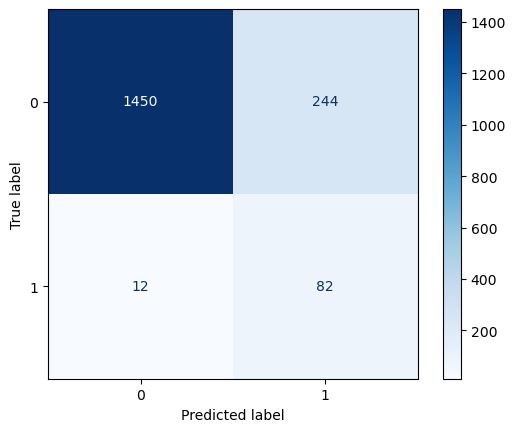

In [151]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

disp.plot(cmap=plt.cm.Blues)
plt.show()

#### AUC 

In [152]:
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_proba)
print(auc)

0.9285023487151147


##  Addressing the Imbalance of the Target

In [153]:
y_test.value_counts()

fraudulent
0    1694
1      94
Name: count, dtype: int64

### Fitting Smote LR model

In [154]:
smote = SMOTE(sampling_strategy='auto', random_state=42)  # auto balances the classes
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [155]:
print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())


Class distribution after SMOTE:
fraudulent
0    13619
1    13619
Name: count, dtype: int64


In [156]:
model_smote = LogisticRegression(max_iter=1000, class_weight='balanced')
model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [157]:
y_pred_smote = model_smote.predict(X_test)

#### Classification Report

In [158]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1694
           1       0.26      0.78      0.39        94

    accuracy                           0.87      1788
   macro avg       0.62      0.83      0.66      1788
weighted avg       0.95      0.87      0.90      1788



#### Confusion Matrix Display

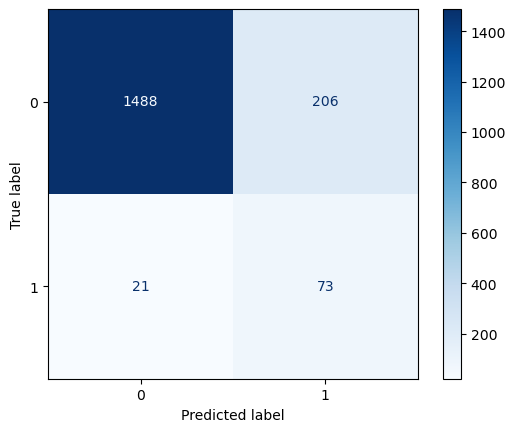

In [159]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=[0, 1])

disp_smote.plot(cmap=plt.cm.Blues)
plt.show()

#### AUC

In [160]:
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

# Calculate AUC
auc_smote = roc_auc_score(y_test, y_proba_smote)
print(auc_smote)

0.9003742872214826


# 4. Random Forest

Introducing a random forest model to test whether it better captures the patterns of the data compared to Logistic Regression. 

### Fitting Random Forest 

In [161]:
model_RF = RandomForestClassifier(n_estimators=1000, random_state=42)
model_RF.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

### Random Forest Predictions

In [162]:
y_pred_RF = model_RF.predict(X_test)

### Classification Report 

In [163]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_RF))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1694
           1       0.87      0.62      0.72        94

    accuracy                           0.97      1788
   macro avg       0.92      0.81      0.85      1788
weighted avg       0.97      0.97      0.97      1788



### Feature Importance of the Random Forest Model 

In [164]:
importances = model_RF.feature_importances_

feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)

feature_imp_df

,Feature,Gini Importance
1,has_company_logo,0.094612
2,has_questions,0.042373
248,function_Administrative,0.032666
226,industry_Oil & Energy,0.027046
3,Salary Given,0.026276
...,...,...
412,Country_SV,0.000000
15,Not Application,0.000000
382,Country_LK,0.000000
375,Country_JM,0.000000


Significantly better results for Random Forest. Now precision is favored over recall. 

### Fitting Smote for Random Forest

In [165]:
model_smote_RF = RandomForestClassifier(n_estimators=1000, random_state=42)
model_smote_RF.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [166]:
y_pred_RF_smote = model_smote_RF.predict(X_test)

In [167]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_RF_smote))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1694
           1       0.41      0.77      0.54        94

    accuracy                           0.93      1788
   macro avg       0.70      0.85      0.75      1788
weighted avg       0.96      0.93      0.94      1788



Recall significantly increased for fake jobs, but precision was diminished. Overall, the quality of prediction is worse for oversampling with Random Forest.